In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
cd /content/drive/MyDrive/

/content/drive/MyDrive


In [4]:
ls

'Colab Notebooks'/   __MACOSX/     taxi_drop/      w_texi_drop/
 KDD2022@            nyc-taxi.h5   taxi_drop.zip


# 1 读取h5历史交通流量数据并观察数据结构

In [4]:
import h5py

# 打开文件
with h5py.File('nyc-taxi.h5', 'r') as f:
    # 打印顶层所有的 key
    print("Keys in the file:", list(f.keys()))
    
    # 递归查看数据集的 shape 和 dtype
    def print_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"Dataset: {name}, Shape: {obj.shape}, Type: {obj.dtype}")

    f.visititems(print_structure)

Keys in the file: ['taxi_drop', 'taxi_pick']
Dataset: taxi_drop, Shape: (4368, 266), Type: int64
Dataset: taxi_pick, Shape: (4368, 266), Type: int64


In [8]:
from matplotlib import pyplot as plt
import matplotlib
a=sorted([f.name for f in matplotlib.font_manager.fontManager.ttflist])

for i in a:
    print(i)

DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans
DejaVu Sans Display
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Sans Mono
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif
DejaVu Serif Display
Humor Sans
Liberation Mono
Liberation Mono
Liberation Mono
Liberation Mono
Liberation Sans
Liberation Sans
Liberation Sans
Liberation Sans
Liberation Sans Narrow
Liberation Sans Narrow
Liberation Sans Narrow
Liberation Sans Narrow
Liberation Serif
Liberation Serif
Liberation Serif
Liberation Serif
STIXGeneral
STIXGeneral
STIXGeneral
STIXGeneral
STIXNonUnicode
STIXNonUnicode
STIXNonUnicode
STIXNonUnicode
STIXSizeFiveSym
STIXSizeFourSym
STIXSizeFourSym
STIXSizeOneSym
STIXSizeOneSym
STIXSizeThreeSym
STIXSizeThreeSym
STIXSizeTwoSym
STIXSizeTwoSym
cmb10
cmex10
cmmi10
cmr10
cmss10
cmsy10
cmtt10


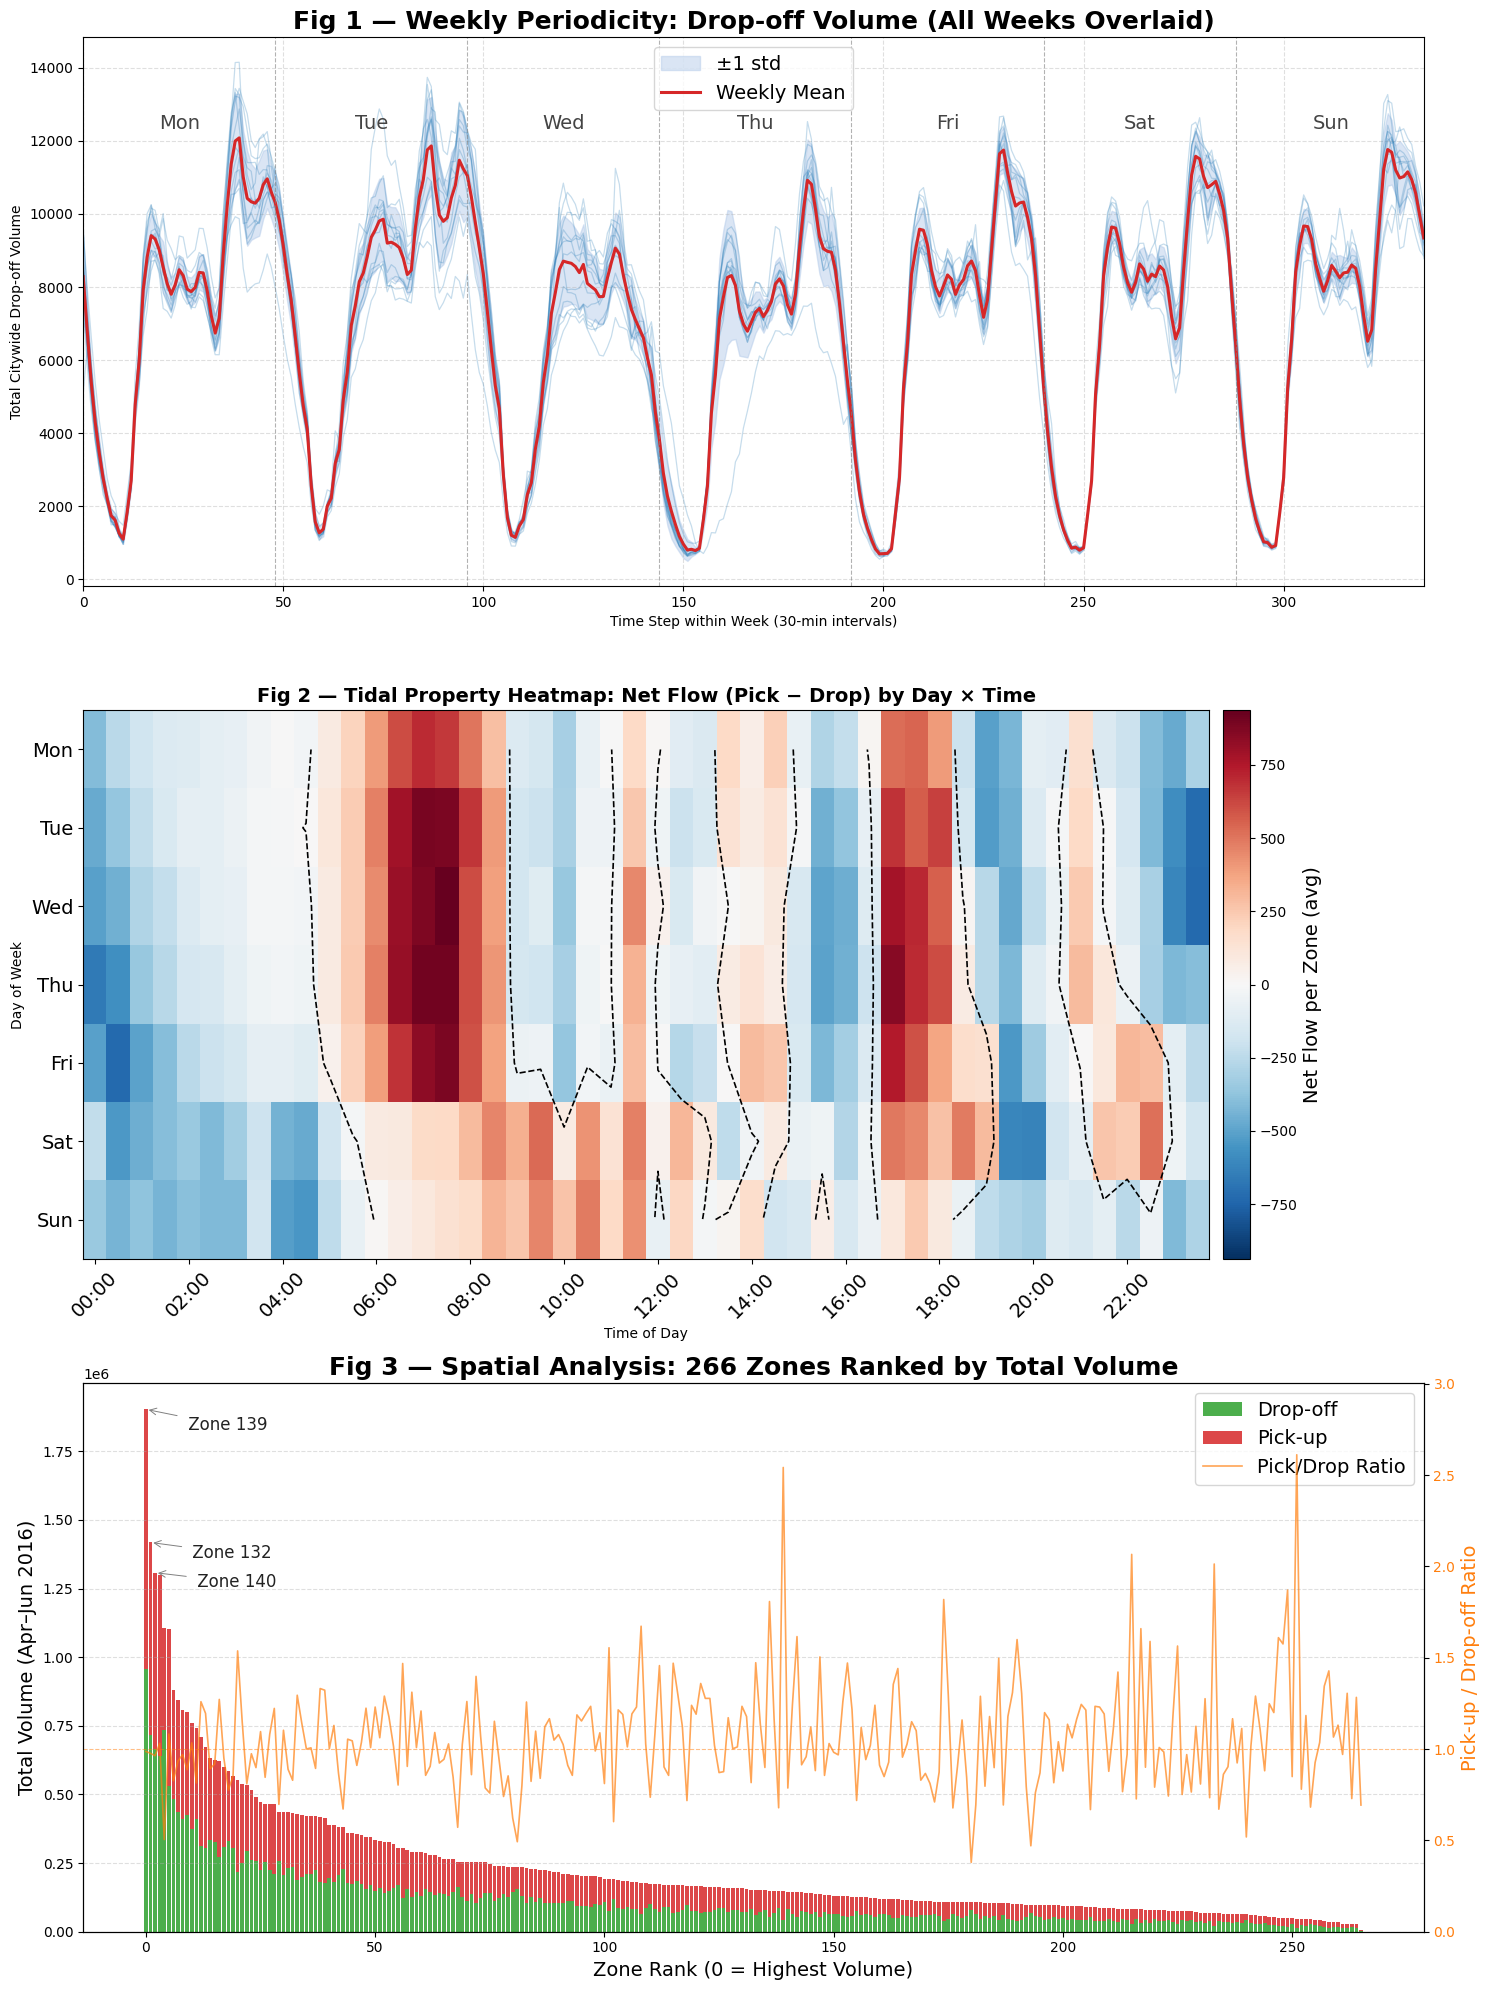

In [7]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 加载数据 ──────────────────────────────────────────────────────────────
with h5py.File('nyc-taxi.h5', 'r') as f:
    drop_data = f['taxi_drop'][:]   # (4368, 266)
    pick_data = f['taxi_pick'][:]   # (4368, 266)

STEPS_PER_DAY  = 48
STEPS_PER_WEEK = STEPS_PER_DAY * 7
N_STEPS        = drop_data.shape[0]   # 4368

# 时间戳（2016-04-01 起，30min 间隔）
timestamps  = pd.date_range("2016-04-01", periods=N_STEPS, freq="30min")
day_of_week = timestamps.dayofweek.values          # Mon=0 … Sun=6
time_of_day = (timestamps.hour * 2 + timestamps.minute // 30).values  # 0-47

total_drop  = drop_data.sum(axis=1)
total_pick  = pick_data.sum(axis=1)

DAY_NAMES = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axs = plt.subplots(3, 1, figsize=(15, 20))
plt.subplots_adjust(hspace=0.50)

# ══════════════════════════════════════════════════════════════════════════════
# 图 1 ── 周周期性：将每一完整周的曲线叠加展示
# ══════════════════════════════════════════════════════════════════════════════
num_complete_weeks = N_STEPS // STEPS_PER_WEEK          # 13 完整周
weekly_drop = total_drop[:num_complete_weeks * STEPS_PER_WEEK] \
              .reshape(num_complete_weeks, STEPS_PER_WEEK)

x_week = np.arange(STEPS_PER_WEEK)
for i in range(num_complete_weeks):
    axs[0].plot(x_week, weekly_drop[i], color='#1f77b4', alpha=0.25, linewidth=0.9)

mean_curve = weekly_drop.mean(axis=0)
std_curve  = weekly_drop.std(axis=0)
axs[0].fill_between(x_week, mean_curve - std_curve, mean_curve + std_curve,
                    color='#aec7e8', alpha=0.45, label='±1 std')
axs[0].plot(x_week, mean_curve, color='#d62728', linewidth=2.2, label='Weekly Mean')

for d in range(7):
    axs[0].axvline(d * STEPS_PER_DAY, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    axs[0].text(d * STEPS_PER_DAY + STEPS_PER_DAY / 2,
                mean_curve.max() * 1.02, DAY_NAMES[d],
                ha='center', fontsize=14, color='#444')

axs[0].set_xlim(0, STEPS_PER_WEEK - 1)
axs[0].set_title('Fig 1 — Weekly Periodicity: Drop-off Volume (All Weeks Overlaid)',
                  fontsize=18, fontweight='bold')
axs[0].set_xlabel('Time Step within Week (30-min intervals)')
axs[0].set_ylabel('Total Citywide Drop-off Volume')
axs[0].legend(fontsize=14)
axs[0].grid(True, linestyle='--', alpha=0.4)

# ══════════════════════════════════════════════════════════════════════════════
# 图 2 ── 潮汐热力图：7 天 × 48 时段，净流量 = Pick − Drop（均值）
# ══════════════════════════════════════════════════════════════════════════════
net_matrix = np.zeros((7, STEPS_PER_DAY))
for dow in range(7):
    for tod in range(STEPS_PER_DAY):
        mask = (day_of_week == dow) & (time_of_day == tod)
        if mask.sum() > 0:
            net_matrix[dow, tod] = (pick_data[mask].sum(axis=1).mean()
                                    - drop_data[mask].sum(axis=1).mean())

vmax = np.abs(net_matrix).max()
im2 = axs[1].imshow(net_matrix, aspect='auto', cmap='RdBu_r',
                    vmin=-vmax, vmax=vmax, interpolation='nearest')

axs[1].set_title('Fig 2 — Tidal Property Heatmap: Net Flow (Pick − Drop) by Day × Time',
                  fontsize=14, fontweight='bold')
axs[1].set_xlabel('Time of Day')
axs[1].set_ylabel('Day of Week')
axs[1].set_yticks(range(7))
axs[1].set_yticklabels(DAY_NAMES, fontsize=14)

hour_ticks = np.arange(0, STEPS_PER_DAY, 4)
axs[1].set_xticks(hour_ticks)
axs[1].set_xticklabels([f'{h // 2:02d}:00' for h in hour_ticks], rotation=45, fontsize=14)

cbar2 = fig.colorbar(im2, ax=axs[1], pad=0.01)
cbar2.set_label('Net Flow per Zone (avg)', fontsize=14)
axs[1].contour(net_matrix, levels=[0], colors='black', linewidths=1.2, linestyles='--')

# ══════════════════════════════════════════════════════════════════════════════
# 图 3 ── 266 个空间位置流量分析：按总量排序 + Pick/Drop 比率
# ══════════════════════════════════════════════════════════════════════════════
zone_drop  = drop_data.sum(axis=0)   # (266,)
zone_pick  = pick_data.sum(axis=0)   # (266,)
zone_total = zone_drop + zone_pick

sorted_idx   = np.argsort(zone_total)[::-1]
zone_drop_s  = zone_drop[sorted_idx]
zone_pick_s  = zone_pick[sorted_idx]
zone_total_s = zone_total[sorted_idx]

x_pos = np.arange(266)
axs[2].bar(x_pos, zone_drop_s, color='#2ca02c', alpha=0.85, label='Drop-off')
axs[2].bar(x_pos, zone_pick_s, bottom=zone_drop_s, color='#d62728', alpha=0.85, label='Pick-up')

ax2r = axs[2].twinx()
ratio = np.where(zone_drop_s > 0, zone_pick_s / zone_drop_s, np.nan)
ax2r.plot(x_pos, ratio, color='#ff7f0e', linewidth=1.2, alpha=0.7, label='Pick/Drop Ratio')
ax2r.axhline(1.0, color='#ff7f0e', linestyle='--', linewidth=0.8, alpha=0.5)
ax2r.set_ylabel('Pick-up / Drop-off Ratio', color='#ff7f0e', fontsize=14)
ax2r.tick_params(axis='y', labelcolor='#ff7f0e')
ax2r.set_ylim(0, np.nanmax(ratio) * 1.15)

for rank in range(3):
    zone_id = sorted_idx[rank]
    axs[2].annotate(f' Zone {zone_id}',
                    xy=(rank, zone_total_s[rank]),
                    xytext=(rank + 8, zone_total_s[rank] * 0.96),
                    fontsize=12, color='#222',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.7))

axs[2].set_title('Fig 3 — Spatial Analysis: 266 Zones Ranked by Total Volume',
                  fontsize=18, fontweight='bold')
axs[2].set_xlabel('Zone Rank (0 = Highest Volume)', fontsize=14)
axs[2].set_ylabel('Total Volume (Apr–Jun 2016)', fontsize=14)

lines1, labels1 = axs[2].get_legend_handles_labels()
lines2, labels2 = ax2r.get_legend_handles_labels()
axs[2].legend(lines1 + lines2, labels1 + labels2, fontsize=14, loc='upper right')
axs[2].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()


# 2 构建含气象信息的交通流量数据集

### 天气信息

In [4]:
import requests
import pandas as pd

def weather_info(start_date = "2016-04-01", end_date = "2016-06-30", lat= 40.7128, lon= -74.0060):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "precipitation",
        "timezone": "America/New_York"
    }
    print(f"正在获取天气数据：{start_date} 至 {end_date} 的NYC历史天气")

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()  # 如果请求失败，会抛出异常

    hourly_data = response.json().get("hourly", {})
    df_hourly = pd.DataFrame({
            "precipitation": hourly_data.get("precipitation", []),   # 单位：mm/h
        },
        index = pd.to_datetime(hourly_data.get("time", [])),  # 逐小时 DatetimeIndex（本地时区）
    )

    idx_30 = pd.date_range(
        start=df_hourly.index[0],
        periods = 4368,
        freq="30min",
    )
    df_30 = df_hourly.reindex(idx_30)  # 先 reindex（整点有值，半点为 NaN），再分别填充
    df_30["precipitation"] = df_hourly["precipitation"].reindex(idx_30, method="ffill") * 0.5  # 向前填充

    return df_30

#测试weather info函数
# df_weather = weather_info()
# df_weather.shape #(4368, 1)

### 天气数据分布可视化

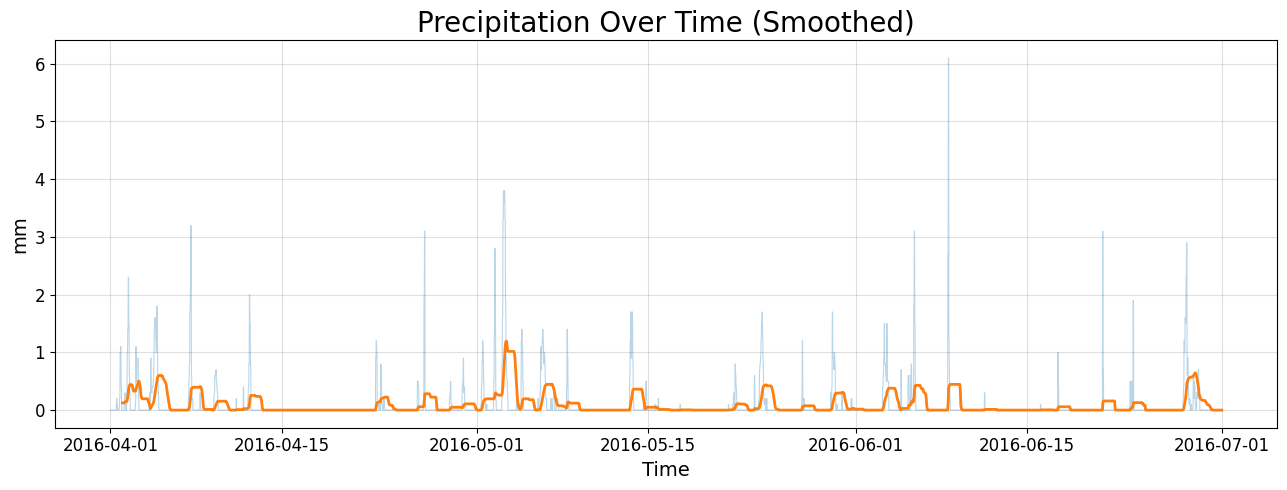

In [ ]:
# import matplotlib.pyplot as plt    
# plt.figure(figsize=(13, 5))

# plt.plot(df_weather.index, df_weather["precipitation"], alpha=0.3, linewidth=0.8)

# smooth = df_weather["precipitation"].rolling(48).mean()
# plt.plot(df_weather.index, smooth, linewidth=2)

# 
# plt.title("Precipitation Over Time (Smoothed)", fontsize=20)
# plt.xlabel("Time", fontsize=14)
# plt.ylabel("mm", fontsize=14)

# 
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# plt.grid(alpha=0.4)
# plt.tight_layout()
# plt.show()



Rainy days: 46
Non-rainy days: 45


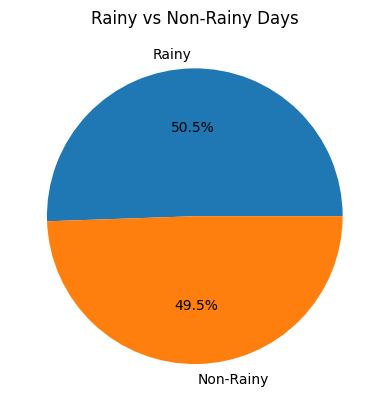

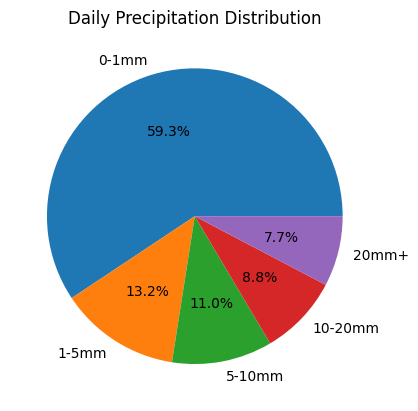

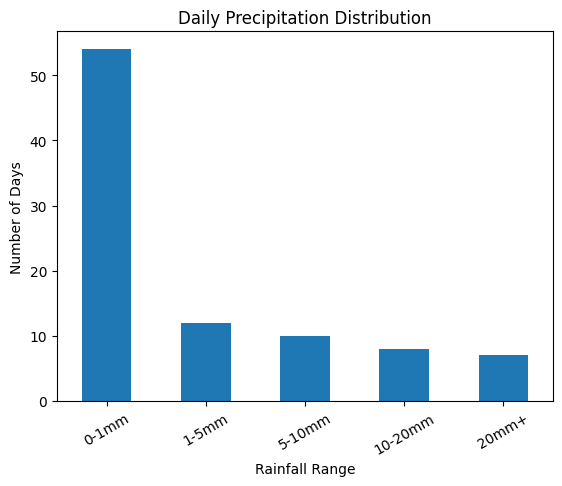

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt


# daily_precip = df_weather["precipitation"].resample("D").sum()

# rainy_days = (daily_precip > 0).sum()
# non_rainy_days = (daily_precip == 0).sum()

# print("Rainy days:", rainy_days)
# print("Non-rainy days:", non_rainy_days)

# plt.figure()
# plt.pie(
#     [rainy_days, non_rainy_days],
#     labels=["Rainy", "Non-Rainy"],
#     autopct="%1.1f%%"
# )
# plt.title("Rainy vs Non-Rainy Days")
# plt.show()


# bins = [0, 1, 5, 10, 20, 50]
# labels = ["0-1mm", "1-5mm", "5-10mm", "10-20mm", "20mm+"]

# rain_distribution = pd.cut(
#     daily_precip,
#     bins=bins,
#     labels=labels,
#     include_lowest=True
# ).value_counts().sort_index()


# plt.figure()
# plt.pie(
#     rain_distribution,
#     labels=rain_distribution.index,
#     autopct="%1.1f%%"
# )
# plt.title("Daily Precipitation Distribution")
# plt.show()


# plt.figure()
# rain_distribution.plot(kind="bar")
# plt.title("Daily Precipitation Distribution")
# plt.xlabel("Rainfall Range")
# plt.ylabel("Number of Days")
# plt.xticks(rotation=30)
# plt.show()


### 数据特征合并与数据集划分

In [5]:
import numpy as np

def generate_seq2seq_data(rawdata, x_offsets, y_offsets, time_features=None, weather_features=None):
    """
    Args:
        rawdata: np.array, shape (num_samples, num_nodes)
        x_offsets: np.array, 历史窗口偏移量, e.g., [-11, ..., 0]
        y_offsets: np.array, 预测窗口偏移量, e.g., [1, ..., 12]
        time_features: np.array, shape (num_samples, 2)
        weather_features: np.array, shape (num_samples, 1)
    Returns:
        x: (epoch_size, input_length, num_nodes, input_dim)
        y: (epoch_size, output_length, num_nodes, 1)
    """
    num_samples, num_nodes = rawdata.shape
    T = num_samples # 总时间步

    # ---- 1. 构建特征矩阵 x_all (T, N, C) ----
    # Channel 0: 交通流量 (T, N, 1)
    x_parts = [rawdata[:, :, np.newaxis].astype(np.float64)]

    # Channel 1-2: 时间特征 (T, 2) -> (T, N, 2)
    # np.tile 使所有节点在同一时刻共享相同的时间特征
    time_3d = np.tile(time_features[:, np.newaxis, :], [1, num_nodes, 1])
    x_parts.append(time_3d.astype(np.float64))

    # Channel 3: 天气特征 (T, 1) -> (T, N, 1)
    weather_3d = np.tile(weather_features[:, np.newaxis, :], [1, num_nodes, 1])
    x_parts.append(weather_3d.astype(np.float64))

    # 沿最后一维拼接：[T，N，4]
    x_all = np.concatenate(x_parts, axis=-1)
    
    # y_all 只预测流量
    y_all = rawdata[:, :, np.newaxis].astype(np.float64)

    print(f"x_all形状: {x_all.shape}")

    # ---- 2. 滑动窗口采样 ----
    x_list, y_list = [], []
    
    # 计算采样的起始和截止索引
    # min_t: 必须能往回看到最远的历史（abs(-11) = 11）
    # max_t: 必须能往后看到最远的未来（num_samples - 12）
    min_t = abs(min(x_offsets))
    max_t = T - max(y_offsets)

    for t in range(min_t, max_t):
        # 根据 offset 提取时间切片
        # x_all[t + x_offsets] 的形状为 (len(x_offsets), num_nodes, input_dim)
        x_list.append(x_all[t + x_offsets, ...])
        # y_all[t + y_offsets] 的形状为 (len(y_offsets), num_nodes, 1)
        y_list.append(y_all[t + y_offsets, ...])

    # 堆叠成最终的 Batch 格式
    x = np.stack(x_list, axis=0) 
    y = np.stack(y_list, axis=0) 

    return x, y

In [ ]:
# 最终 channel 结构（input_dim=6）：
#   x: [drop流量, time_in_day比例, day_of_week, precipitation]
#   y: [drop流量]  ← 只预测流量，不预测天气
import h5py
import os
import numpy as np
import pandas as pd

def generate_dataset(h5_path='nyc-taxi.h5', past=12, future=12):
    # 1. 读取交通数据
    with h5py.File(h5_path, 'r') as f:
        # 只取 "taxi_drop" 键
        rawdata = np.array(f["taxi_drop"])  # (num_samples, num_nodes)
    
    num_samples, num_nodes = rawdata.shape

    # 2. 生成时间特征
    timestamps = pd.date_range(
        start="2016-04-01 00:00:00",
        freq="30min",
        periods=num_samples
    )
    time_in_day = (timestamps.hour * 60 + timestamps.minute) / (24 * 60)
    day_of_week = timestamps.dayofweek.astype(np.float64)
    time_features = np.stack([time_in_day, day_of_week], axis=-1)  # (num_samples, 2)

    # 3. 获取天气特征 (确保转为 numpy)
    df_weather = weather_info() 
    weather_features = df_weather.values # 转换为 numpy 数组，解决 InvalidIndexError
    
    # # 确保天气数据行数对齐
    # if weather_features.shape[0] != num_samples:
    #     print(f"警告：天气数据({weather_features.shape[0]})与交通数据({num_samples})行数不一致！")
    #     # 这里可能需要根据你的实际数据逻辑进行对齐（截断或重索引）

    x_offsets = np.arange(-past + 1, 1)
    y_offsets = np.arange(1, future + 1)

    # 4. 融合特征 (确保传入的都是 numpy 数组)
    x, y = generate_seq2seq_data(
        rawdata, 
        x_offsets, 
        y_offsets, 
        time_features, 
        weather_features
    )
    print(f"生成数据 x shape: {x.shape}, y shape: {y.shape}")

    # 5. 划分数据集 (解决浮点数索引问题)
    data_num = x.shape[0]
    num_test = int(data_num * 0.2)
    num_val = int(data_num * 0.2)
    num_train = data_num - num_test - num_val
    
    # 明确定义切片点，确保严丝合缝
    split_val = num_train
    split_test = num_train + num_val

    print(f"样本划分 — train: {num_train}, val: {num_val}, test: {num_test}")

    datasets = {
        "train": (x[:split_val], y[:split_val]),
        "val":   (x[split_val:split_test], y[split_val:split_test]),
        "test":  (x[split_test:], y[split_test:])
    }

    # 6. 创建输出目录并保存
    save_folder = "./w_texi_drop"
    os.makedirs(save_folder, exist_ok=True)

    for cat, (data_x, data_y) in datasets.items():
        print(f"  正在保存 {cat}: x={data_x.shape}, y={data_y.shape}")
        np.savez_compressed(
            os.path.join(save_folder, f"{cat}.npz"),
            x=data_x,
            y=data_y,
            x_offsets=x_offsets.reshape(-1, 1),
            y_offsets=y_offsets.reshape(-1, 1),
        )
    
    print(f"\n所有文件已成功保存至 ./{save_folder}/")
    return True

In [16]:
if __name__ == "__main__":
    generate_dataset()

正在获取天气数据：2016-04-01 至 2016-06-30 的NYC历史天气
x_all形状: (4368, 266, 4)
生成数据 x shape: (4345, 12, 266, 4), y shape: (4345, 12, 266, 1)
样本划分 — train: 2607, val: 869, test: 869
  正在保存 train: x=(2607, 12, 266, 4), y=(2607, 12, 266, 1)
  正在保存 val: x=(869, 12, 266, 4), y=(869, 12, 266, 1)
  正在保存 test: x=(869, 12, 266, 4), y=(869, 12, 266, 1)

所有文件已成功保存至 ././w_texi_drop/


# 测试数据集构建准确性

In [17]:
# 测试数据集
import numpy as np
import os
import torch
from torch.utils.data import TensorDataset, DataLoader

def load_dataset(dataset_dir, batch_size, valid_batch_size=None, test_batch_size=None):
    data = {}
    for category in ["train", "val", "test"]:
        cat_data = np.load(os.path.join(dataset_dir, category + ".npz"))
        data["x_" + category] = cat_data["x"]
        data["y_" + category] = cat_data["y"]

    train_ds = TensorDataset(torch.Tensor(data["x_train"]), torch.Tensor(data["y_train"]))
    val_ds   = TensorDataset(torch.Tensor(data["x_val"]),   torch.Tensor(data["y_val"]))

    data["train_loader"] = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    data["val_loader"] = DataLoader(val_ds, batch_size=valid_batch_size, shuffle=False)

    # test_ds  = TensorDataset(torch.Tensor(data["x_test"]),  torch.Tensor(data["y_test"]))
    # data["test_loader"] = DataLoader(test_ds, batch_size=test_batch_size, shuffle=False)
    
    return data

In [20]:
"""测试dataLoader模块"""
dataset_dir = "w_texi_drop"
taxi_drop_data = load_dataset(dataset_dir, batch_size=32, valid_batch_size=32, test_batch_size=32)

In [21]:
example_x, example_y = next(iter(taxi_drop_data["train_loader"]))
print("Example x shape:", example_x.shape)  # (batch_size, num_time_steps, locations, channels)
print("Example y shape:", example_y.shape)  # (batch_size, num_time_steps, locations, 1)

Example x shape: torch.Size([32, 12, 266, 4])
Example y shape: torch.Size([32, 12, 266, 1])


In [22]:
print(example_x)

tensor([[[[5.4000e+01, 3.9583e-01, 6.0000e+00, 7.0000e-01],
          [7.8000e+01, 3.9583e-01, 6.0000e+00, 7.0000e-01],
          [2.3000e+01, 3.9583e-01, 6.0000e+00, 7.0000e-01],
          ...,
          [2.2000e+01, 3.9583e-01, 6.0000e+00, 7.0000e-01],
          [7.8000e+01, 3.9583e-01, 6.0000e+00, 7.0000e-01],
          [4.0000e+00, 3.9583e-01, 6.0000e+00, 7.0000e-01]],

         [[7.7000e+01, 4.1667e-01, 6.0000e+00, 4.5000e-01],
          [1.0000e+02, 4.1667e-01, 6.0000e+00, 4.5000e-01],
          [2.3000e+01, 4.1667e-01, 6.0000e+00, 4.5000e-01],
          ...,
          [1.8000e+01, 4.1667e-01, 6.0000e+00, 4.5000e-01],
          [8.5000e+01, 4.1667e-01, 6.0000e+00, 4.5000e-01],
          [8.0000e+00, 4.1667e-01, 6.0000e+00, 4.5000e-01]],

         [[8.4000e+01, 4.3750e-01, 6.0000e+00, 4.5000e-01],
          [1.0500e+02, 4.3750e-01, 6.0000e+00, 4.5000e-01],
          [4.3000e+01, 4.3750e-01, 6.0000e+00, 4.5000e-01],
          ...,
          [2.1000e+01, 4.3750e-01, 6.0000e+00, 4.50